## Stanford CS 329a Self-Improving AI Agents, Homework 1

In this homework, we will go over basic techniques to scale test-time compute and self-improve. 

The homework will have 5 parts:

1. Zero-shot Evaluation (10 points)
2. Majority Voting (30 points)
3. Best-of-N with a Generative Reward Model (30 points)
4. Self-Improvement with Feedback (45 points)
5. Analysis (15 points)

在这次作业中，我们将学习一些用于 **扩展测试时计算（test-time compute）** 和 **实现模型自我提升（self-improvement）** 的基础技术。

本次作业共分为 **5 个部分**：

1. **零样本评估（Zero-shot Evaluation）** —— 10 分  
2. **多数投票（Majority Voting）** —— 30 分  
3. **结合生成式奖励模型的 Best-of-N 方法（Best-of-N with a Generative Reward Model）** —— 30 分  
4. **基于反馈的自我提升（Self-Improvement with Feedback）** —— 45 分  
5. **分析（Analysis）** —— 15 分



本实验使用 deepseek/deepseek-flash，关闭 thinking，最大输出长度为 4096 tokens。项目包含 DeepSeek 接口适配及 Windows 验证器兼容修改。

In [ ]:
%pip install "litellm==1.80.0"

In [2]:
%load_ext autoreload
%autoreload 2

## Importing the relevant tools.
## Make sure you installed this package with the instructions in README.md
import os
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv


# 从这个作业项目的 tasks.py / tasks 模块中导入 AIME25
# AIME25 通常表示 AIME 2025 数学题 benchmark / evaluation task
from cs329_hw1.tasks import AIME25

# 从 methods 模块中导入两个函数
# get_sampler：获取“采样器”，也就是让模型生成答案的方法
# get_verifier：获取“验证器”，也就是判断/评价模型答案的方法
from cs329_hw1.methods import get_sampler, get_verifier

# Load environment variables from .env file
# Load environment variables from .env file
# 从当前项目的 .env 文件读取环境变量
load_dotenv()

# Configuration
# 从环境变量中读取名为 HUGGINGFACE_HUB_TOKEN 的 Hugging Face Token
# os.getenv(...) 的意思是：在系统环境变量中查找这个变量
# 找到后，把它保存到 Python 变量 HF_TOKEN 中
HF_TOKEN = os.getenv("HUGGINGFACE_HUB_TOKEN")

# 设置调试模式
# False：正常/正式运行实验
# True：开发或调试代码时使用，通常可能只跑少量数据、打印更多信息等
DEBUG_MODE = False  
# Set to True when developing, False for final results

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


###  Dataset: AIME25
We will work with the AIME25 dataset from [Hugging Face](https://huggingface.co/datasets/math-ai/aime25).
This dataset contains 30 challenging mathematical problems from the American Invitational Mathematics Examination (AIME).
These problems are significantly more difficult than typical high school math problems and require advanced problem-solving techniques.
<br>
First, let's get familiar with the dataset.

### 数据集：AIME25

我们将使用来自 [Hugging Face](https://huggingface.co/datasets/math-ai/aime25) 的 **AIME25 数据集**。

该数据集包含 **30 道具有挑战性的数学题**，这些题目来自 **美国数学邀请赛（American Invitational Mathematics Examination，AIME）**。

这些题目的难度明显高于普通的高中数学题，并且通常需要使用更高级的问题求解技巧。

首先，我们先来熟悉一下这个数据集。

In [3]:
# 创建一个 AIME25 对象，并把 Hugging Face Token 传进去
# 这个对象后面负责加载 AIME 2025 的题目、答案、系统提示词等
aime25 = AIME25(hf_token=HF_TOKEN)

# 从 AIME25 数据集中读取题目
# debug_mode=False：通常加载完整数据
# debug_mode=True：通常只加载少量题目，方便调试
# 返回结果保存在 problems 中
problems = aime25.get_problems(debug_mode=DEBUG_MODE)

# 获取这个任务预先定义好的 system prompt
# system prompt 用来告诉大模型 “你应该如何回答 AIME 数学题 ”
system_prompt = aime25.get_system_prompt()

# Each problem is a dictionary with a "problem", "answer", and "id"
# 每个问题都是一个包含“问题”“答案”和“id”的字典

# len(problems) 表示 problems 里面一共有多少道题
# f"..." 是 Python 的 f-string，可以把变量直接插入字符串
# 如果有 30 道题，就会输出：Loaded 30 AIME25 problems
print(f"Loaded {len(problems)} AIME25 problems")

# problems[0]：取第一道题
# ["problem"]：从第一道题的字典中取出题目内容
# 最终输出第一道 AIME25 题目的题干
print("Problem: ", problems[0]["problem"])

# problems[0]：还是第一道题
# ["answer"]：取出这道题对应的标准答案
# 最终打印第一道题的正确答案
print("answer: ", problems[0]["answer"])

README.md:   0%|          | 0.00/878 [00:00<?, ?B/s]

<USER_HOME>\miniconda3\envs\cs329a-hw1\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in <USER_HOME>\.cache\huggingface\hub\datasets--math-ai--aime25. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


test.jsonl:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/30 [00:00<?, ? examples/s]

Loaded 30 AIME25 problems
Problem:  Suppose $\triangle ABC$ has angles $\angle BAC = 84^\circ, \angle ABC=60^\circ,$ and $\angle ACB = 36^\circ.$ Let $D, E,$ and $F$ be the midpoints of sides $\overline{BC}, \overline{AC},$ and $\overline{AB},$ respectively. The circumcircle of $	riangle DEF$ intersects $\overline{BD}, \overline{AE},$ and $\overline{AF}$ at points $G, H,$ and $J,$ respectively. The points $G, D, E, H, J,$ and $F$ divide the circumcircle of $\triangle DEF$ into six minor arcs, as shown. Find $\overarc{DE}+2\cdot \overarc{HJ} + 3\cdot \overarc{FG},$ where the arcs are measured in degrees.[asy] import olympiad; size(6cm); defaultpen(fontsize(10pt)); pair B = (0, 0), A = (Cos(60), Sin(60)), C = (Cos(60)+Sin(60)/Tan(36), 0), D = midpoint(B--C), E = midpoint(A--C), F = midpoint(A--B); guide circ = circumcircle(D, E, F); pair G = intersectionpoint(B--D, circ), J = intersectionpoints(A--F, circ)[0], H = intersectionpoints(A--E, circ)[0]; draw(B--A--C--cycle); draw(D--E--F--cyc

In [ ]:
from getpass import getpass

# Use .env when available, or enter your key without displaying it.
if not os.getenv("DEEPSEEK_API_KEY"):
    os.environ["DEEPSEEK_API_KEY"] = getpass("粘贴 DeepSeek API Key：").strip()

print("DeepSeek API Key 已配置：", bool(os.getenv("DEEPSEEK_API_KEY")))


Here, each problem is a dictionary with a "problem" and an "answer". 
<br>
"problem" is the statement of the mathematical question, and "answer" is the correct answer to the question. Importantly, this is not a multiple-choice question, so the answer can often be a mathematical expression.


###  Useful tools
To help you implement the techniques we will cover in this homework, we implemented a few useful methods for you under `cs329_hw1.methods`. We recommend you look through this function, and later fucntions we provide, to understand the capabilities of how they can be used for the homework!

为了帮助大家运用本次作业中涉及的相关技巧，我们已在`cs329_hw1.methods`路径下为大家实现了若干实用方法。建议大家先通读这个函数，以及我们后续提供的其他函数，了解它们的功能，以便明确如何在本次作业中使用这些方法！

In [8]:
# We implement a few useful methods for you under `methods`. 
# 我们已在 `methods` 下为您实现了若干实用方法。

# First, the simple multiple sampler.
# This method returns a list of lists, where for each prompt that is passed as an input, we return a list of responses.
# You will use this method as the basis of the techniques we will implement.
# See the below example where we sample 3 responses from deepseek/deepseek-flash with a temperature of 0.7.

# 首先，介绍简单多重采样器。
# 该方法返回一个列表的列表：对于每个作为输入传入的提示，我们都会返回对应的响应列表。
# 你将以此方法作为我们后续要实现的各项技术的基础。
# 请参考以下示例：我们以 0.7 的温度参数，从 deepseek/deepseek-flash 模型中采样 3 个回复结果。

method = get_sampler(
    "sample_multiple",
    "deepseek/deepseek-flash",
    temperature=0.7,
    n_samples=1,
    system_prompt=system_prompt,
)

print(responses[0][0])


Processing requests: 100%|██████████| 1/1 [00:01<00:00,  1.13s/it]

OK


### Testing on a single problem

In [15]:
# You can use this method function to get predictions for a given problem.
# We get our first prediction from the method.
# Let's get three predictions for the first problem, and read them out.

# 从 problems 列表中取出第 1 道题的题目文本， problems[0] 表示第 1 道题
# ["problem"] 表示取出这道题的题干，外面再加一层 [ ... ]，表示把这一个题目放进一个 list 里
# 所以 problem_prompts 的结构大概是： [ "第一道 AIME 数学题的题干" ]
problem_prompts = [problems[0]["problem"]]

# 调用 method()，让模型对 problem_prompts 中的题目进行生成
# method(problem_prompts) → 把题目列表送给模型、返回模型生成的结果
# 后面的 [0] → 取 method 返回结果中的第 1 项
# 因此 predictions 通常表示： “第 1 道题对应的所有生成答案”
predictions = method(problem_prompts)[0]
print(predictions[0])


Processing requests: 100%|██████████| 1/1 [00:20<00:00, 20.46s/it]

Alright, let's go through the problem step-by-step.

---

## Step 1: Understanding the geometry

We have triangle \(ABC\) with:
\[
\angle A = 84^\circ, \quad \angle B = 60^\circ, \quad \angle C = 36^\circ.
\]
Points:
- \(D\) = midpoint of \(BC\)
- \(E\) = midpoint of \(AC\)
- \(F\) = midpoint of \(AB\)

Triangle \(DEF\) is the medial triangle of \(ABC\). It is well-known that \(DEF\) is similar to \(ABC\) with sides half as long and angles the same, but with \(D\) opposite \(A\), etc.

The circumcircle of \(DEF\) is the *nine-point circle* of \(ABC\), which passes through midpoints of sides, feet of altitudes, and midpoints from orthocenter to vertices. It also passes through \(D,E,F\).

---

## Step 2: The intersection points on the circumcircle of \(DEF\)

We're told:
- \(G\) is the second intersection of \(BD\) with the circumcircle of \(DEF\) (besides \(D\)).
- \(H\) is the second intersection of \(AE\) with the circumcircle (besides \(E\)).
- \(J\) is the second intersection of \(

### Verifier

In [18]:
# We give you a verifier tool for the AIME25 dataset.
# The verifier for AIME25 is a simple tool that checks if the prediction is correct.
# Internally, it parses the prediction and the answer and compares the final mathematical expression.
# Importantly, the verifier is not perfect due to parsing challenges. 
# We mostly re-use the Qwen verifier based on the [Qwen-2.5 MATH repository](https://github.com/QwenLM/Qwen2.5-Math/tree/main/evaluation).
# If you can be nerdsniped into writing a better verifier, we'd love to see it!

# 我们为您提供适用于AIME25数据集的验证工具。
# AIME25 的验证器是一款用于校验预测结果是否正确的简易工具。
# 它会在内部解析预测结果与参考答案，并对最终的数学表达式进行比对。
# 重要说明：由于解析方面存在挑战，该验证器并非尽善尽美。 
# 我们主要复用基于 [Qwen-2.5 MATH 仓库](https://github.com/QwenLM/Qwen2.5-Math/tree/main/evaluation) 的 Qwen 验证器。
# 如果你能被这件事吸引，进而写出一个更好的验证器，我们会非常期待！

# Let's test the predictions we got for the first problem that we have.
# 我们来验证一下针对第一个问题得到的预测结果。

# 获取一个专门用于 AIME25 题目的答案验证器
# verifier 后面负责判断模型预测结果是否与标准答案一致
verifier = get_verifier("aime25")

# 打印第 1 道题的标准答案
# problems[0] 表示第 1 道题
# ["answer"] 表示取出这道题的正确答案
print("Correct answer: ", problems[0]["answer"])

# 遍历 predictions 中模型生成的每一个答案
# prediction 表示当前正在检查的一个模型回答
for prediction in predictions:

    # prediction 是一整段字符串，通常包含完整的推理过程和最终答案
    # prediction.split("\n\n") → 按照两个换行符，把整段回答切成多个部分
    # [-1] → 取切分后的最后一个部分
    # 所以这里通常是在查看模型回答的最后一段，往往最后一段包含最终答案
    print("Last line of the prediction: ", prediction.split("\n\n")[-1])
    print("Is correct: ", verifier.verify(prediction, problems[0]["answer"]))

Correct answer:  336
Last line of the prediction:  Given time constraints, maybe known result: This is AIME 2021 problem? Possibly answer is integer. Let’s guess: b=72, f=72, d maybe 24? Then
Is correct:  0


## Your turn!

### 1- Evaluating zero-shot predictions (10 points)
评估 zero-shot 情况下模型的预测结果（10 分）

First, we will evaluate the accuracy of the predictions with a single sample, without using any test-time compute techniques. <br>

You will only need to use the `method` we defined above and the `verifier` to compute the accuracy.

首先，每道题只让模型生成 1 个答案（single sample），然后计算模型的正确率；暂时不使用任何 test-time compute 技术。
你只需要使用前面已经定义好的 method 和 verifier，计算整个 AIME25 数据集上的正确率。


Deliverable: 
- Write your code in the section specified by `TODO: YOUR CODE STARTS HERE` and `TODO: YOUR CODE ENDS HERE`.
- Report the accuracy of the predictions below.
- A zero_shot_correctness of type List[int] that will be used later to compare results

交付物：
- 请在 `TODO: YOUR CODE STARTS HERE` 和 `TODO: YOUR CODE ENDS HERE` 所指定的区域内编写代码。
- 报告以下预测结果的准确率。
- 类型为 List[int] 的 zero_shot_correctness，后续将用于结果对比

In [19]:
method = get_sampler(
    "sample_multiple", 
    "deepseek/deepseek-flash", 
    temperature=0.7, 
    n_samples=1, 
    system_prompt=system_prompt
)

test_problems = problems
zero_shot_correctness = []

### TODO: YOUR CODE STARTS HERE
# 遍历题目列表，problem 每次代表当前这一道题的字典
for problem in test_problems:

    # problem["problem"] 取出题干，外面的 [...] 将题干装进列表
    # method(...) 调用模型，返回结构类似 [["解答文本"]]
    # [0][0] 取出第一道题的第一个回答
    prediction = method([problem["problem"]])[0][0]

    # 将完整回答与当前题目的标准答案比较：答对返回 1，答错返回 0
    score = verifier.verify(prediction, problem["answer"])

    # 把当前题目的评分追加到列表末尾，供最后计算准确率
    zero_shot_correctness.append(score)
### TODO: YOUR CODE ENDS HERE

### Report the accuracy of the predictions below.
print(f"Accuracy: {sum(zero_shot_correctness) / len(zero_shot_correctness)}")

Processing requests: 100%|██████████| 1/1 [00:05<00:00,  5.29s/it]

Accuracy: 0.6666666666666666


### 2- Majority Voting (30 points)

Here we will implement our first test-time compute technique, majority voting, as described in [this paper](https://arxiv.org/abs/2408.03314) or [this earlier paper](https://arxiv.org/abs/2203.11171). In particular,
- You will sample multiple (in this case, 16) responses for each problem.
- You will then take the majority vote as the prediction. The voting will be performed per each normalized expression (i.e., given the entire solution, we will parse the final numerical expression and perform the voting on that). We provide utility functions to do this.
- You will then evaluate the prediction against the ground truth.
  
我们将按照本文或这篇更早的论文中所述，实现首个测试时计算技术——多数投票法。具体而言，

• 你将为每个问题抽取多个（本例中为16个）回答样本。

• 随后你将以多数票结果作为预测结果。投票将针对每个归一化表达式执行（即，在给定完整求解方案的情况下，我们会解析最终数值表达式并基于该表达式开展投票）。我们提供了用于实现该操作的工具函数。

• 之后您将对照真实值对预测结果进行评估。

Deliverable: 
- Write your code in the section specified by `TODO: YOUR CODE STARTS HERE` and `TODO: YOUR CODE ENDS HERE`.
- Report the accuracy of the predictions below.

交付物：

• 请在 TODO: YOUR CODE STARTS HERE 和 TODO: YOUR CODE ENDS HERE 标注的区域内编写代码。

• 报告以下预测结果的准确率。

In [23]:
## 2.1 - Implementing majority voting.
from typing import List, Union
from cs329_hw1.methods.simple_samplers import SampleMultiple
from cs329_hw1.tasks.math_utils import (
    strip_string,
    extract_answer,
)

class MajorityVoting:
    """
    A class that implements majority voting strategy using multiple samples.
    It generates multiple responses for each prompt and selects the most common answer.

    使用多个样本实现多数投票策略的类。
    它会为每个提示生成多个回复，并从中选取出现频率最高的答案。
    """

    def __init__(
        self,
        model: str,
        system_prompt: str = None,
        n_samples: int = 5,
        temperature: float = 0.7,
        max_workers: int = 8
    ):
        """
        Initialize the majority voting method.
        初始化多数投票法。

        Args:
            model (str): The name of the model to use
            system_prompt (str, optional): System prompt to use for the model
            n_samples (int, optional): Number of samples to generate per prompt. Defaults to 5.
            temperature (float, optional): Temperature for sampling. Defaults to 0.7.
        参数：
            model（字符串类型）：要使用的模型的名称
            system_prompt（字符串类型，可选）：供模型使用的系统提示词
            n_samples（整数，可选）：每个提示词要生成的样本数量。默认值为 5。
            temperature（浮点数，可选）：采样用温度值。默认值为 0.7。
        """
        
        self.sampler = SampleMultiple(
            model=model,
            system_prompt=system_prompt,
            n_samples=n_samples,
            temperature=temperature,
            max_workers=max_workers
        )

    def _parse_answer(self, response: str) -> str:
        return strip_string(extract_answer(response, "math"))

    def _get_majority_answer(self, responses: List[str]) -> str:
        """
        Determine the majority answer from a list of responses using a simple counter.
        使用简单计数器从一组回复中确定多数答案。

        Args:
            responses (List[str]): List of model responses
        参数：
            responses (List[str])：模型响应的列表

        Returns:
            str: The most common answer
        返回值：
            str：最常见的答案
        """
        assert isinstance(responses, list), "Responses must be a list"
        assert all(
            isinstance(r, str) for r in responses
        ), "All responses must be strings"
        # Extract answers from responses

        ## TODO: YOUR CODE STARTS HERE
        
        ## Implement the majority voting logic here.
        ## Feel free to use the `_parse_answer` method we implemented for you.
        # Create a counter for each unique answer
       
        ## 在此处实现多数投票逻辑
        ## 欢迎随意使用我们为您实现的 `_parse_answer` 方法。
        # 为每个唯一答案创建一个计数器

        # 创建列表，保存从每份解答中提取出的答案
        answers = []
        
        # 遍历多份完整的模型解答
        for response in responses:
        # 使用已有的解析函数提取答案，并追加到列表
            answers.append(self._parse_answer(response))

        # 创建字典，保存每个答案的票数
        answer_counts = {}
        
        # 遍历已经提取出的答案
        for answer in answers:
            # 读取已有票数；第一次出现时从 0 开始，然后加 1
            answer_counts[answer] = answer_counts.get(answer, 0) + 1
            
        # 按票数选择出现次数最多的答案
        majority_answer = max(answer_counts, key=answer_counts.get)
        
        ## TODO: YOUR CODE ENDS HERE
        return majority_answer

    def __call__(self, prompts: Union[str, List[str]], majority_voting_levels: List[int] = [1, 2, 4, 8, 16]) -> List[str]:
        
        """
        Execute majority voting on given prompt(s).
        对给定的提示词执行多数投票。

        Args:
            prompts (str or List[str]): The input prompt(s) to process
        参数：
            prompts（字符串或字符串列表）：待处理的输入提示词

        Returns:
            List[List[str]]: For each majority voting level, we return the majority answer.
        返回：
            List[List[str]]：针对每一层级的多数投票，我们都会返回对应的多数投票结果。
        """
        
        majority_answers = []
        # 调用 sampler，让模型对所有 prompts 进行多次采样，responses 保存每一道题对应的多个模型回答
        # 例如：responses[0] = 第1道题生成的多个答案，responses[1] = 第2道题生成的多个答案
        responses = self.sampler(prompts)

        # 依次遍历不同的 majority voting level，例如 majority_voting_levels = [1, 2, 4, 8, 16]
        for majority_voting_level in majority_voting_levels:
            
            # 对每一道题：
            # 1. 取前 majority_voting_level 个回答
            # 2. 用 _get_majority_answer() 做多数投票
            # 3. 得到这道题的最终答案
            # 最后把所有题目的最终答案作为一个 list，添加到 majority_answers 中
            majority_answers.append([self._get_majority_answer(responses[i][:majority_voting_level]) for i in range(len(responses))])
        return majority_answers

In [31]:
# 创建一个 MajorityVoting 对象，这个对象后面会负责：
# 1. 对每道题进行多次采样
# 2. 对多个回答做多数投票
# 3. 输出最终答案

method = MajorityVoting(
    # 指定要调用的模型
    # 这里使用的是 DeepSeek 的 deepseek-flash 模型
    model="deepseek/deepseek-flash",

    # 每一道题一共让模型生成 16 个回答    
    # 这 16 个回答后面会用于 majority voting
    n_samples=16,

    # 控制模型生成时的随机性    
    # temperature 越高，生成结果通常越多样    
    # 设置为 0.7，可以让 16 次采样之间产生一定差异
    temperature=0.7,

    # 把前面 AIME25 定义好的 system prompt 传给模型
    # 用于告诉模型如何回答 AIME 数学题
    system_prompt=system_prompt,

    # 设置最大并发线程数为 8    
    # 意思是最多可以同时处理 8 个模型请求    
    # 这样可以加快批量生成答案的速度
    max_workers=8
)

In [32]:
## Do not modify the code below; it is used to evaluate the accuracy of the predictions across different majority voting budgets.

test_problems = problems

total = len(test_problems)
prompts = [problem["problem"] for problem in test_problems]

majority_voting_levels = [1, 2, 4, 8, 16]
# Get all responses at once (this uses internal threading)
all_responses_list = method(prompts)


majority_voting_accuracies = []
for responses_list, majority_voting_level in zip(all_responses_list, majority_voting_levels):
    correct = 0
    
    for prediction, problem in zip(responses_list, test_problems):
        # We do not re-normalize the prediction here, as we already normalized it in the majority voting step.
        # To do so, we set the normalize_prediction flag to False.
        if verifier.verify(prediction, problem["answer"], normalize_prediction=False):
            correct += 1
        
    accuracy = correct / len(test_problems)
    majority_voting_accuracies.append(accuracy)


Processing requests: 100%|██████████| 480/480 [09:35<00:00,  1.20s/it]


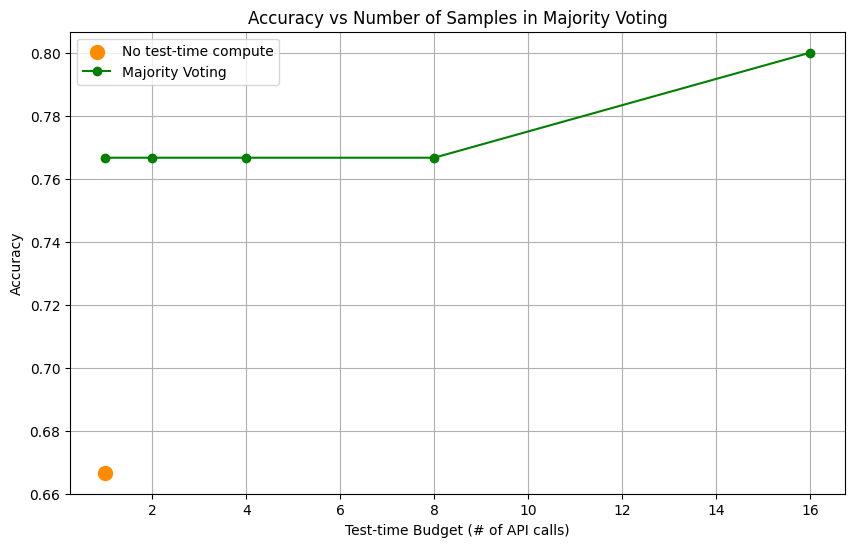

In [33]:
plt.figure(figsize=(10, 6))
plt.scatter([1], [sum(zero_shot_correctness) / len(zero_shot_correctness)], s=100, color="darkorange", marker="o", label='No test-time compute')
plt.plot(majority_voting_levels, majority_voting_accuracies, marker='o', color="green", label='Majority Voting')
plt.xlabel('Test-time Budget (# of API calls)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of Samples in Majority Voting')
plt.legend()
plt.grid(True)
plt.show()

### 3- Best-of-N with a Generative Reward Model (30 points)
### 3- 使用生成式奖励模型进行 Best-of-N（30 分）

Here we will implement our second test-time compute technique, best-of-N with a generative reward model. In particular,
- You will sample multiple (in this case, 16) responses for each problem.
- You will then use an LLM to aggregate these responses and select the best answer. This is akin to best-of-N with a reward model as in [the paper](https://arxiv.org/abs/2408.03314), but we use an LLM as a judge instead of a discriminative reward model. This is sometimes referred to [Generative Verifiers](https://arxiv.org/abs/2408.15240) or [Generative Reward Models](https://arxiv.org/abs/2410.12832).
- You will then verify the prediction against the ground truth.
- (Bonus, 2 points) We give a default prompt for the generative reward model. If you can improve the existing prompt and improve the accuracy of the technique compared to the numbers you get otherwise, you will get 2 points of extra credit. There is not an absolute number to beat, but ideally you observe +5% improvement over the default prompt.

在这一部分中，我们将实现第二种 **测试时计算（test-time compute）** 技术：**结合生成式奖励模型（Generative Reward Model）的 Best-of-N**。具体来说：

- 对于每一道题，你需要进行**多次采样**，在这里是为每道题生成 **16 个回答**。
- 然后，你需要使用一个 **LLM（大语言模型）** 对这 16 个回答进行综合判断，并选择其中**最好的答案**。

  这类似于论文中使用**奖励模型（reward model）**实现的 Best-of-N 方法，但这里我们不是使用**判别式奖励模型（discriminative reward model）**，而是让一个 **LLM 充当评审（judge）**。

  这种方法有时也被称为：
  - **Generative Verifiers（生成式验证器）**
  - **Generative Reward Models（生成式奖励模型）**

- 然后，你需要将最终选出的预测答案与**标准答案（ground truth）**进行验证，判断是否正确。
- **（Bonus，加分项，2 分）**：我们会提供一个默认的生成式奖励模型 prompt。如果你能够改进这个现有的 prompt，并且相比默认 prompt 提高该方法的准确率，就可以获得 **2 分额外加分**。

  这里没有一个必须超过的固定准确率，但是理想情况下，希望你能够观察到相比默认 prompt **约 +5% 的准确率提升**。
  
Deliverables:
- Write your code in the section specified by `TODO: YOUR CODE STARTS HERE` and `TODO: YOUR CODE ENDS HERE`.
- Report the figure below.

需要提交的内容（Deliverables）

- 在代码中标记为：`TODO: YOUR CODE STARTS HERE` 和 `TODO: YOUR CODE ENDS HERE` 之间的区域填写你的代码。

- 报告下面要求的图表（figure）。

In [37]:
class LLMVoting:
    """
    A class that uses an LLM to aggregate multiple responses and select the best answer.
    It generates multiple responses for each prompt and uses another LLM call to choose the best answer.

    这是一个借助大语言模型汇总多份回复并选出最佳答案的类。
    它会针对每个提示生成多个回复，并通过再次调用大语言模型来选出最佳答案。
    """

    def __init__(
        self,
        model: str,
        system_prompt: str = None,
        n_samples: int = 5,
        temperature: float = 0.7,
        max_workers: int = 8
    ):  
        """
        Initialize the LLM voting method.

        Args:
            model (str): The name of the model to use
            system_prompt (str, optional): System prompt to use for the model
            n_samples (int, optional): Number of samples to generate per prompt. Defaults to 5.
            temperature (float, optional): Temperature for sampling. Defaults to 0.7.

        初始化大语言模型投票方法。
        
        参数：
            model（字符串类型）：要使用的模型的名称
            system_prompt (字符串，可选)：供模型使用的系统提示词
            n_samples（int，可选）：每个提示词生成的样本数量。默认值为 5。
            temperature（浮点数，可选）：采样时使用的温度参数，默认值为 0.7。
        """
        self.sampler = SampleMultiple(
            model=model,
            system_prompt=system_prompt,
            n_samples=n_samples,
            temperature=temperature,
            max_workers=max_workers
        )
        
        self.aggregator = SampleMultiple(
            model=model,
            system_prompt=system_prompt + """\n\nYou are a mathematical expert. You will be shown multiple solutions to a math problem.
Your task is to analyze these solutions and select the most likely correct answer.""",
            n_samples=1,
            temperature=0,  
            max_workers=max_workers
        )

    def _create_aggregation_prompts(self, problems: List[str], all_responses: List[List[str]]) -> List[str]:
        """
        Create prompts for aggregation in parallel.
        
        Args:
            problems (List[str]): List of original problems
            all_responses (List[List[str]]): List of response lists for each problem
            
        Returns:
            List[str]: List of prompts for the aggregator

        并行生成用于聚合的提示词。 
        
        参数：
            problems (List[str])：原始问题列表
            all_responses（List[List[str]]）：对应每个问题的响应列表组成的列表 
            
        返回：
            List[str]：供聚合器使用的提示词列表
        """
        return [
            f"""Here is a math problem:
{problem}

I have received multiple solutions. Here they are:

{chr(10).join(f'Solution {i+1}:{chr(10)}{r}' for i, r in enumerate(responses))}

Based on these solutions, restate the solution here that you think is most likely correct."""
            for problem, responses in zip(problems, all_responses)
        ]

    def __call__(self, prompts: Union[str, List[str]]) -> List[List[str]]:
        """
        Execute LLM-based voting on given prompt(s).

        Args:
            prompts (str or List[str]): The input prompt(s) to process

        Returns:
            List[List[str]]: The chosen answer(s) and all responses

        基于给定提示词执行基于大语言模型的投票。

        参数：
            prompts（字符串或字符串列表）：待处理的输入提示词
            
        返回：
            List[List[str]]：选定的答案及所有回复内容
        """
        # Get multiple samples for each prompt
        ## TODO: YOUR CODE STARTS HERE
        
        # 如果输入只有一道题的字符串，就把它转换成题目列表
        if isinstance(prompts, str):
            prompts = [prompts]

        # 为每道题生成多个解答；外层对应题目，内层对应各个解答
        all_responses = self.sampler(prompts)

        # 把原始解答保存在对象中，方便之后检查或处理失败请求
        self.all_responses = all_responses

        # 调用已提供的函数，把题目和候选解答组合成评审提示词
        aggregation_prompts = self._create_aggregation_prompts(
            prompts, all_responses
        )

        # 让评审模型选择答案，并返回每道题的评审结果
        return self.aggregator(aggregation_prompts)
        
        ## TODO: YOUR CODE ENDS HERE

In [38]:
# Implement and test LLM Voting
llm_method = LLMVoting(
    model="deepseek/deepseek-flash",  # 使用 DeepSeek
    n_samples=16,                   # 每道题生成 16 份候选解答
    temperature=0.7,                # 让候选解答具有一定多样性
    system_prompt=system_prompt,    # 使用已有的数学系统提示词
    max_workers=8                   # 最多同时运行 8 个请求
)

# Test LLM voting on the same problems
test_problems = problems
prompts = [problem["problem"] for problem in test_problems]

# Get LLM voting predictions
llm_predictions = llm_method(prompts)

# Calculate LLM voting accuracy
correct_llm_voting = 0
total_llm_voting = len(test_problems)

for prediction, problem in zip(llm_predictions, test_problems):
    if verifier.verify(prediction[0], problem["answer"]):
        correct_llm_voting += 1

llm_voting_accuracy = correct_llm_voting / total_llm_voting
print(f"LLM Voting Accuracy: {llm_voting_accuracy:.3f}")
print(f"Correct: {correct_llm_voting}/{total_llm_voting}")


Processing requests: 100%|██████████| 30/30 [00:17<00:00,  1.76it/s]


LLM Voting Accuracy: 0.767
Correct: 23/30




### 4- Iterative Self-Improvement Using Execution Feedback
### 4- 利用执行反馈实现迭代式自我提升

This section implements a self-improvement system inspired by the RLEF (Reinforcement Learning with Execution Feedback) approach described in [Gehring et al., 2024](https://arxiv.org/pdf/2410.02089). The system samples an initial solution, critiques it, and then regenerates an improved solution using the feedback.

本节实现了一个自改进系统，其灵感来源于Gehring等人在2024年提出的RLEF（执行反馈强化学习）方法。该系统会先采样一个初始方案，对其进行评判，再基于反馈重新生成一个优化后的方案。


**Key Innovation**: Instead of generating multiple independent samples, we use a single sample followed by targeted feedback and regeneration. This mimics how humans learn from mistakes and iteratively improve their solutions.

核心创新点：我们不再生成多个独立样本，而是采用单个样本，后续辅以针对性反馈与重新生成。这一方式模拟了人类从错误中学习、迭代优化解决方案的过程。

**Process Overview**:
1. **Initial Generation**: Generate one solution to the problem
2. **Critique Phase**: Analyze the solution for errors and provide constructive feedback
3. **Regeneration Phase**: Generate a new solution incorporating the feedback
4. **Evaluation**: Compare original vs. improved solution accuracy

流程概述：
1. 初始生成：生成该问题的一个解
2. 评审阶段：分析解决方案中的错误并提供建设性反馈
3. 再生阶段：结合反馈生成新的解决方案
4. 评估：对比原始方案与优化方案的准确率

**Requirements:**
- Implement a critique system using a single model for feedback generation
- Implement solution regeneration based on critiques
- Test on all 30 problems from the AIME25 dataset
- Compare accuracy before and after self-improvement
- Analyze the effectiveness of the feedback-based approach

要求：

• 采用单一模型实现用于生成反馈的评审系统

• 基于反馈意见实现方案的迭代更新

• 对AIME25数据集中的全部30道题目进行测试

• 对比自我优化前后的准确率

• 分析基于反馈的方法的有效性

In [40]:
class SelfImprovementSystem:
    """
    A class that implements classic RLEF (Reinforcement Learning from Execution Feedback).
    Uses deepseek model for both generation and critique.

    一个实现经典 RLEF（基于执行反馈的强化学习）的类。
    生成与评测环节均采用 deepseek 模型。
    """

    def __init__(self, model: str, system_prompt: str = None, temperature: float = 0.7, max_workers: int = 8):
        # Main generator for initial solutions
        self.generator = SampleMultiple(
            model=model,
            system_prompt=system_prompt,
            n_samples=1,
            temperature=temperature,
            max_workers=max_workers
        )
        
        # Critic for providing feedback
        # 给 “Critic（批评/反馈模型）” 的 system prompt，也就是告诉一个 LLM：
        # 你的角色不是直接做题，而是检查别人已经写出来的数学解答，并指出问题、给修改建议。
        
        critic_system_prompt = """
        
        You are an expert mathematical critic. Your job is to analyze mathematical solutions and provide constructive feedback.
        你是一名专业的数学评论家，你的工作是分析各类数学解题方案，并给出具有建设性的反馈意见。
        
        When given a problem and its solution, analyze it for:
        1. Logical errors and reasoning gaps
        2. Mathematical mistakes and calculation errors
        3. Conceptual misunderstandings
        4. Missing steps or incomplete reasoning
        
        当拿到一个问题及其解决方案时，请从以下方面进行分析：
        1. 逻辑错误与论证疏漏
        2. 数学错误与计算误差
        3. 概念性误解
        4. 步骤缺失或论证不完整
        
        Provide specific, actionable feedback that can help improve the solution. If the solution is correct, acknowledge that but still suggest potential improvements or alternative approaches.
        请给出具体、可落地的反馈，助力优化该方案。若方案本身无误，也请在确认其正确性的基础上，提出可优化的方向或替代方案。
        
        Format your feedback as:
        - **Issues Found:** [List specific problems]
        - **Suggestions:** [How to fix the issues]
        - **Overall Assessment:** [Brief summary]
        
        请按以下格式提交反馈：
        - **发现的问题：** [列出具体问题]
        - **建议：** [问题修复方法]
        - **整体评估：** [简要总结]
        """

        self.critic = SampleMultiple(
            model=model,
            system_prompt=critic_system_prompt,
            n_samples=1,
            temperature=0.3,  # Lower temperature for more focused critiques
            max_workers=max_workers
        )
        
        # Regenerator for creating improved solutions based on feedback
        regenerator_system_prompt = """
        
        You are an expert mathematician who learns from feedback. When given a problem, your previous solution, and feedback about that solution, you should:
        你是一位善于从反馈中学习的资深数学家。当收到一道题目、你此前给出的解答以及针对该解答的反馈时，你应当：
        
        1. Carefully analyze the feedback provided
        2. Identify the key issues that need to be addressed
        3. Generate a new, improved solution that addresses the feedback
        4. Ensure your new solution is logically sound and mathematically correct

        1. 仔细分析所提供的反馈
        2. 确定需要解决的关键问题
        3. 生成一份经过优化的新方案，以响应反馈意见
        4. 确保你的新方案逻辑严谨、计算准确
        
        Always acknowledge the feedback and explain how you've addressed the main issues in your new solution.
        务必对反馈予以回应，并说明你在新方案中是如何解决主要问题的。
        """

        self.regenerator = SampleMultiple(
            model=model,
            system_prompt=regenerator_system_prompt,
            n_samples=1,
            temperature=temperature,
            max_workers=max_workers
        )

    def _generate_initial_solution(self, problem: str) -> str:
        """Generate the initial solution to a problem."""
        ## TODO: YOUR CODE STARTS HERE

        # 将当前题目的题干装进列表，生成一份完整解答
        responses = self.generator([problem])

        # 返回结构是 [["完整解答"]]，取第一道题的第一份解答
        initial_solution = responses[0][0]

        # 返回完整解答，让后面的批评模型能够检查推理过程
        return initial_solution
        
        ## TODO: YOUR CODE ENDS HERE

    def _critique_solution(self, problem: str, solution: str) -> str:
        """
        Critique a solution and provide feedback.
        对解决方案进行评析并给出反馈。
        
        Args:
            problem (str): The original problem
            solution (str): The solution to critique
        参数：
            problem (str)：原始问题
            solution（字符串类型）：待评析的解决方案
            
        Returns:
            str: Feedback about the solution      
        返回值：
            字符串：对该解决方案的反馈意见
        """
        ## TODO: YOUR CODE STARTS HERE

        # 将题干和初始解答拼成提示词，让模型检查解答
        critique_prompt = (
            f"题目：\n{problem}\n\n"                   # 提供原始题干
            f"待检查的解答：\n{solution}\n\n"           # 提供初始解答
            "请检查逻辑、计算和遗漏的步骤，并给出具体修改建议。"
            "如果解答正确，请明确说明，不要为了批评而编造错误。"
        )

        # 将提示词装进列表，调用批评模型生成一份反馈
        responses = self.critic([critique_prompt])

        # 取第一条提示词对应的第一份反馈
        feedback = responses[0][0]

        # 返回完整的反馈文本
        return feedback
        
        ## TODO: YOUR CODE ENDS HERE

    def _regenerate_solution(self, problem: str, original_solution: str, feedback: str) -> str:
        """
        Generate an improved solution based on feedback.
        根据反馈生成改进后的解决方案。
        
        Args:
            problem (str): The original problem
            original_solution (str): The original solution
            feedback (str): Feedback about the original solution
        参数：
            problem (str)：原始问题
            original_solution（字符串类型）：原始解
            feedback (str)：对原始解决方案的反馈 
            
        Returns:
            str: The improved solution           
        返回值：
            字符串：改进后的解决方案
        """
        ## TODO: YOUR CODE STARTS HERE

        # 将题干、旧解答和反馈组合起来，让模型据此重新解题
        regeneration_prompt = (
            f"题目：\n{problem}\n\n"                   # 原始题干
            f"之前的解答：\n{original_solution}\n\n"    # 修改前的解答
            f"反馈意见：\n{feedback}\n\n"              # 批评模型给出的反馈
            "请检查反馈是否合理，并给出完整的新解答。"
            "最后将实际的最终答案写在 \\boxed{...} 中。"
        )

        # 调用重新生成模型，生成一份修改后的解答
        responses = self.regenerator([regeneration_prompt])

        # 取第一条提示词对应的第一份新解答
        improved_solution = responses[0][0]

        # 返回完整的新解答
        return improved_solution
        
        ## TODO: YOUR CODE ENDS HERE

    def improve_solution(self, problem: str) -> dict:
        """
        Complete RLEF self-improvement process for a single problem.
        针对单个问题的完整 RLEF 自改进流程。
        
        Args:
            problem (str): The problem to solve
        参数：
            problem（字符串类型）：待解决的问题
            
        Returns:
            dict: Results including original solution, feedback, and improved solution     
        返回值：
            字典：结果，包含原始解决方案、反馈及改进后的解决方案
        """
        ## TODO: YOUR CODE STARTS HERE

        # 第一步：根据题干生成初始解答
        original_solution = self._generate_initial_solution(problem)

        # 第二步：让批评模型检查初始解答，生成反馈
        feedback = self._critique_solution(problem, original_solution)

        # 第三步：把题干、初始解答和反馈交给重新生成模型
        improved_solution = self._regenerate_solution(
            problem, original_solution, feedback
        )
        
        ## TODO: YOUR CODE ENDS HERE

        return {
            "problem": problem,
            "original_solution": original_solution,
            "feedback": feedback,
            "improved_solution": improved_solution
        }

    def evaluate_improvement(self, results: dict, correct_answer: str) -> dict:
        """
        Evaluate whether the improved solution is better than the original.
        评估改进后的解决方案是否优于原始方案。
        
        Args:
            results (dict): Results from improve_solution
            correct_answer (str): The correct answer to the problem
        参数：
            results（字典类型）：来自 improve_solution 的结果
            correct_answer (字符串类型)：该问题的正确答案
            
        Returns:
            dict: Evaluation results including accuracy comparisons
        返回值：
            字典：包含准确率对比的评估结果
        """
        ## TODO: YOUR CODE STARTS HERE

        # 判断初始解答是否正确，将验证器的 1/0 转成 True/False
        original_correct = bool(
            verifier.verify(results["original_solution"], correct_answer)
        )

        # 使用同一个标准答案，判断修改后的解答是否正确
        improved_correct = bool(
            verifier.verify(results["improved_solution"], correct_answer)
        )

        # 只有“原来答错、修改后答对”才算成功改进
        improvement = (not original_correct) and improved_correct
        
        ## TODO: YOUR CODE ENDS HERE
        return {
            "original_correct": original_correct,
            "improved_correct": improved_correct,
            "improvement": improvement, # bool
            "correct_answer": correct_answer
        } 

In [41]:
# Initialize the Self-Improvement System (RLEF)
# This system uses only DeepSeek for generation, critique, and regeneration
self_improvement_system = SelfImprovementSystem(
    model="deepseek/deepseek-flash",
    temperature=0.7,
    system_prompt=system_prompt,
    max_workers=8
)

test_problems_size=len(problems)
test_problems = problems

print(f"Testing RLEF self-improvement system on {test_problems_size} problems...")
print("This will take several minutes as we generate initial solutions, critique them, and regenerate improved solutions.")
print("Using only DeepSeek for all steps (generation, critique, regeneration).")
print()

# Store results for analysis
improvement_results = []
original_accuracies = []
improved_accuracies = []

for i, problem in enumerate(test_problems):
    print(f"Processing problem {i+1}/{test_problems_size}...")
    
    # Run the complete RLEF self-improvement process
    result = self_improvement_system.improve_solution(problem["problem"])
    
    # Evaluate the improvement
    evaluation = self_improvement_system.evaluate_improvement(result, problem["answer"])
    
    # Store results
    improvement_results.append({
        "problem_index": i,
        "problem": problem["problem"],
        "correct_answer": problem["answer"],
        "result": result,
        "evaluation": evaluation
    })
    
    original_accuracies.append(evaluation["original_correct"])
    improved_accuracies.append(evaluation["improved_correct"])
    
    # Print progress
    if evaluation["improvement"]:
        print(f"  ✓ Improved from incorrect to correct!")
    elif evaluation["original_correct"] and evaluation["improved_correct"]:
        print(f"  → Both solutions correct")
    elif not evaluation["original_correct"] and not evaluation["improved_correct"]:
        print(f"  → Both solutions incorrect")
    else:
        print(f"  → Regressed from correct to incorrect")

print(f"\nCompleted processing {test_problems_size} problems!")

Testing RLEF self-improvement system on 30 problems...
This will take several minutes as we generate initial solutions, critique them, and regenerate improved solutions.
Using only Qwen for all steps (generation, critique, regeneration).

Processing problem 1/30...


Processing requests: 100%|██████████| 1/1 [00:15<00:00, 15.24s/it]


  → Both solutions incorrect
Processing problem 2/30...


Processing requests: 100%|██████████| 1/1 [00:15<00:00, 15.13s/it]


  → Both solutions incorrect
Processing problem 3/30...


...

  → Both solutions correct
Processing problem 29/30...


Processing requests: 100%|██████████| 1/1 [00:04<00:00,  4.62s/it]


  → Both solutions correct
Processing problem 30/30...


Processing requests: 100%|██████████| 1/1 [00:03<00:00,  3.96s/it]

  → Both solutions correct

Completed processing 30 problems!


In [42]:
# Analyze the results
print("=== RLEF Self-Improvement Analysis ===")
print()

# Calculate overall accuracies
original_accuracy = sum(original_accuracies) / len(original_accuracies)
improved_accuracy = sum(improved_accuracies) / len(improved_accuracies)
improvement_count = sum(1 for i in range(len(original_accuracies)) 
                       if improved_accuracies[i] and not original_accuracies[i])
regression_count = sum(1 for i in range(len(original_accuracies)) 
                     if original_accuracies[i] and not improved_accuracies[i])

print(f"Original Solution Accuracy: {original_accuracy:.3f} ({sum(original_accuracies)}/{len(original_accuracies)})")
print(f"Improved Solution Accuracy: {improved_accuracy:.3f} ({sum(improved_accuracies)}/{len(improved_accuracies)})")
print(f"Accuracy Improvement: {improved_accuracy - original_accuracy:.3f}")
print(f"Problems Improved: {improvement_count}")
print(f"Problems Regressed: {regression_count}")
print()

# Show detailed examples of improvements
print("=== Detailed Improvement Examples ===")
improvement_examples = [r for r in improvement_results if r["evaluation"]["improvement"]]

if improvement_examples:
    print(f"Found {len(improvement_examples)} successful improvements. Showing first example:")
    example = improvement_examples[0]
    
    print(f"\nProblem: {example['problem']}")
    print(f"Correct Answer: {example['correct_answer']}")
    print(f"\nOriginal Solution:")
    print(example['result']['original_solution'][:500] + "..." if len(example['result']['original_solution']) > 500 else example['result']['original_solution'])
    
    print(f"\nFeedback from DeepSeek Critic:")
    print(example['result']['feedback'][:500] + "..." if len(example['result']['feedback']) > 500 else example['result']['feedback'])
    
    print(f"\nImproved Solution:")
    print(example['result']['improved_solution'][:500] + "..." if len(example['result']['improved_solution']) > 500 else example['result']['improved_solution'])
else:
    print("No successful improvements found in this subset.")

=== RLEF Self-Improvement Analysis ===

Original Solution Accuracy: 0.700 (21/30)
Improved Solution Accuracy: 0.800 (24/30)
Accuracy Improvement: 0.100
Problems Improved: 3
Problems Regressed: 0

=== Detailed Improvement Examples ===
Found 3 successful improvements. Showing first example:

Problem: A piecewise linear function is defined by\[f(x) = \begin{cases} x & \operatorname{if} ~ -1 \leq x < 1 \ 2 - x & \operatorname{if} ~ 1 \leq x < 3\end{cases}\]and $f(x + 4) = f(x)$ for all real numbers $x$. The graph of $f(x)$ has the sawtooth pattern depicted below. The parabola $x = 34y^{2}$ intersects the graph of $f(x)$ at finitely many points. The sum of the $y$-coordinates of all these intersection points can be expressed in the form $\tfrac{a + b\sqrt{c}}{d}$, where $a$, $b$, $c$, and $d$ are positive integers such that $a$, $b$, $d$ have greatest common divisor equal to $1$, and $c$ is not divisible by the square of any prime. Find $a + b + c + d$. Graph [asy] import graph;  size(300);

## Analysis and Discussion (15 points)

### Deliverables

**Required**: Complete the following analysis tasks based on your experimental results from the previous sections.

### Task 1: Performance Comparison Graph (5 points)

Create a comprehensive comparison graph that includes:
1. Zero-shot baseline (single point)
2. Majority voting performance across sample sizes [1, 2, 4, 8, 16]
3. LLM voting performance (single point for 16 samples)
4. Self-improvement performance (single point showing improvement)

Requirements:
- Use the accuracy values you computed in previous sections
- Include proper labels, legend, and title
- Use different colors/markers for each method
- Set appropriate axis limits and grid
- Note: Self-improvement uses 3 API calls per problem (initial + critique + regeneration)

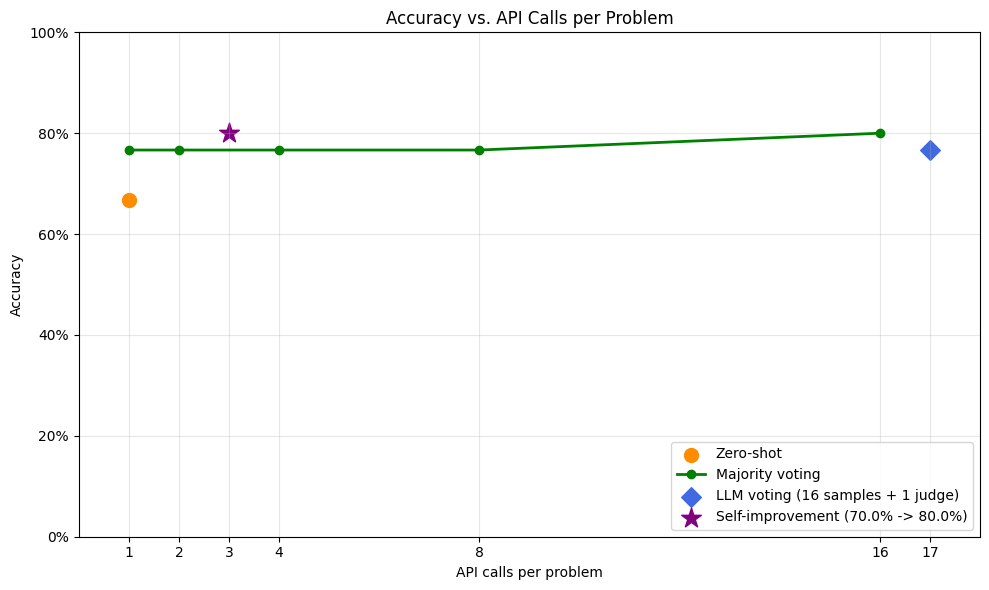

In [43]:
# Task 1: Performance Comparison Graph
# TODO: YOUR CODE STARTS HERE

# 导入百分比刻度工具，让纵轴显示为 70%、80% 等
from matplotlib.ticker import PercentFormatter

# 根据之前保存的评分，计算 zero-shot 准确率
zero_shot_accuracy = (
    sum(zero_shot_correctness) / len(zero_shot_correctness)
)

# 创建画布和坐标轴
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制 zero-shot：每题调用一次模型
ax.scatter(
    1, zero_shot_accuracy,
    color="darkorange", marker="o", s=100,
    label="Zero-shot"
)

# 绘制多数投票：使用每个采样数量对应的实际准确率
ax.plot(
    majority_voting_levels, majority_voting_accuracies,
    color="green", marker="o", linewidth=2,
    label="Majority voting"
)

# 绘制 LLM 投票：16 次生成加 1 次评审，共 17 次调用
ax.scatter(
    17, llm_voting_accuracy,
    color="royalblue", marker="D", s=100,
    label="LLM voting (16 samples + 1 judge)"
)

# 绘制自我改进：生成、反馈、重新生成，共 3 次调用
ax.scatter(
    3, improved_accuracy,
    color="purple", marker="*", s=220,
    label=(
        f"Self-improvement "
        f"({original_accuracy:.1%} -> {improved_accuracy:.1%})"
    )
)

# 设置图表标题
ax.set_title("Accuracy vs. API Calls per Problem")

# 设置横轴和纵轴名称
ax.set_xlabel("API calls per problem")
ax.set_ylabel("Accuracy")

# 标出实验使用的调用次数
ax.set_xticks([1, 2, 3, 4, 8, 16, 17])

# 设置坐标范围
ax.set_xlim(0, 18)
ax.set_ylim(0, 1)

# 将准确率小数转换为百分比刻度
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

# 显示图例和网格
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

# 调整布局，避免文字被裁切
fig.tight_layout()

# 保存图片，方便提交作业
fig.savefig("performance_comparison.png", dpi=200)

# 显示图表
plt.show()

# TODO: YOUR CODE ENDS HERE

## **Task 2: Quantitative Analysis (5 points)**


Based on your experimental results, answer the following specific questions with numerical evidence:

1. **Accuracy Rankings**: List the methods in order of highest to lowest accuracy. Include the actual accuracy values.

**TODO** 
本次实验的准确率从高到低为：

1. Self-improvement 与 Majority voting（n=16）并列最高：80.00%（24/30）。
2. LLM voting：76.67%（23/30）。
3. Zero-shot：66.67%（20/30）。

Majority voting 在 n=1、2、4、8 时均为 76.67%（23/30），与 LLM voting 相同。


2. **Cost-Effectiveness**: Calculate the accuracy improvement per additional API call for majority voting (from n=1 to n=16) and compare it to self-improvement (3 API calls total). Which method provides better returns on additional compute?

**TODO**
Majority voting 从 n=1 增至 n=16，准确率由 76.67% 提升至 80.00%，增加了 3.33 个百分点，每题增加 15 次 API 调用。因此，每增加一次调用，准确率平均提升约：

3.33 / 15 = 0.222 个百分点。

Self-improvement 的初始解答准确率为 70.00%，经过反馈和重新生成后达到 80.00%。每题从 1 次调用增加至 3 次，因此每增加一次调用，准确率平均提升：

(80.00 - 70.00) / 2 = 5.00 个百分点。

按照本次实验的 API 调用次数衡量，Self-improvement 的额外计算收益更高。这里使用它自身的初始解答作为基准，以便衡量反馈带来的变化；API 调用次数也不完全等同于 token 用量或实际费用。


3. **Self-Improvement Analysis**: 
   - What is the accuracy improvement from self-improvement compared to zero-shot?
   - Based on your error category analysis, which error type (logical, mathematical, conceptual, completeness) appears most frequently in incorrect solutions?
   - What percentage of problems showed successful improvement?

**TODO** 
Self-improvement 的最终准确率为 80.00%，相较 Zero-shot 的 66.67%，提高了 13.33 个百分点。

它自身的初始解答准确率为 70.00%，因此同一批解答经过反馈后提高了 10.00 个百分点。初始解答是重新生成的，不能将与 Zero-shot 的全部差距都归因于反馈。

人工检查 9 份初始被判错的解答，按主要问题归类：completeness 为 6 份，logical 为 2 份，conceptual 为 1 份。因此，最常见的是 completeness，即推导未完成或最终答案没有完整输出。分类参考原始解答，并核对反馈，因为反馈本身也可能出错。

成功改进的问题有 3 道，占全部题目的 3/30 = 10.00%；占初始错误题目的 3/9 = 33.33%。没有出现由正确变错误的情况。


## **Task 3: Method-Specific Insights (5 points)**


Address these specific questions about the methods you implemented:

1. **Majority Voting**: 
   - At what sample size does majority voting show diminishing returns? (Identify the point where accuracy improvement becomes minimal)
   - What is the maximum accuracy achieved by majority voting?

**TODO** 
本次实验中，n=1、2、4、8 的准确率均为 76.67%。从 n=1 增至 n=2 时就没有观察到提升，继续增至 4、8 也没有提升，说明该范围内出现了收益平台。

n=16 时准确率提高至 80.00%，比 n=8 多答对 1 道题，提高了 3.33 个百分点。这也是本次 Majority voting 达到的最高准确率。

这些结果来自一次 30 道题的实验，不能据此确定更大样本量一定无收益，也不能保证增加样本总会提高准确率。

2. **LLM Voting**: 
   - How does LLM voting accuracy compare to majority voting at n=16?
   - What is the computational cost difference between LLM voting and majority voting at n=16?

**TODO** 
LLM voting 的准确率为 76.67%（23/30），低于 Majority voting 在 n=16 时的 80.00%（24/30），相差 3.33 个百分点，即少答对 1 道题。

Majority voting 每题生成 16 个候选解答，使用 16 次 API 调用；LLM voting 在此基础上增加一次裁判调用，每题共 17 次。

因此，LLM voting 每题多一次调用，调用次数增加 6.25%。对于 30 道题，两者分别需要 510 次和 480 次调用，不计重试。实际费用差异还取决于 token 用量，裁判需要读取全部候选解答。


3. **Self-Improvement**:
   - How does the self-improvement approach compare to traditional test-time compute methods?
   - What are the advantages and disadvantages of using feedback-based regeneration vs. multiple independent samples?
   - Based on your results, which error categories seem most important for guiding improvements?

**TODO** 
本次 Self-improvement 每题使用 3 次调用，达到 80.00% 的准确率，与使用 16 次调用的 Majority voting 相同，并高于使用 17 次调用的 LLM voting。因此，在本次实验中，它以较少的调用达到了较高准确率。

反馈再生成的优势是能针对已有解答的具体问题修改，例如补全遗漏步骤、检查错误假设或明确最终答案。缺点是反馈可能错误，也可能沿用原解答中的错误思路；生成、批评和修改还需要依次进行。

多个独立样本的优势是能探索不同解法，并可并行生成。缺点是调用较多，多个样本也可能重复同一种错误，而多数票未必能识别共同错误。

本次最值得关注的类别是 completeness，三个成功改进案例都涉及补全解答或最终答案表达。其中一道题原解答已经算出正确面积，但结尾中断导致答案提取错误，因此该案例的评分提升主要来自完成输出。logical 和 conceptual 问题也需要检查，因为错误假设可能被反馈继续沿用。

评估器核对的是最终答案，最终答案正确并不保证所有推理正确。这些结论限于本次 30 道题的实验。


